In [2]:
pip install -q kagglehub tensorflow matplotlib seaborn scikit-learn opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "alamshihab075/brain-tumor-mri-dataset-for-deep-learning"
)

print(dataset_path)

C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1


In [5]:
import os

print("Dataset Path:")
print(dataset_path)

print("\nFolders:")

for folder in os.listdir(dataset_path):
    print(folder)

Dataset Path:
C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1

Folders:
test
Train


In [6]:
data_dir = os.path.join(dataset_path, "Train")

print(data_dir)
print(os.listdir(data_dir))

C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1\Train
['Train']


In [7]:
print(data_dir)

C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1\Train


In [8]:
import os

print("dataset_path =", dataset_path)

print("\nContents:")

for item in os.listdir(dataset_path):
    print(item)

dataset_path = C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1

Contents:
test
Train


In [9]:
data_dir = os.path.join(dataset_path, "Train")

print(data_dir)

print(os.listdir(data_dir))

C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1\Train
['Train']


In [10]:
import os

root_dir = r"C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1"

train_dir = os.path.join(root_dir, "Train", "Train")
test_dir = os.path.join(root_dir, "test", "test")

print(train_dir)
print(test_dir)

print(os.listdir(train_dir))

C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1\Train\Train
C:\Users\nagar\.cache\kagglehub\datasets\alamshihab075\brain-tumor-mri-dataset-for-deep-learning\versions\1\test\test
['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


In [11]:
classes = sorted(os.listdir(train_dir))

for cls in classes:
    img_folder = os.path.join(train_dir, cls, "images")
    print(cls, len(os.listdir(img_folder)))

Glioma 3157
Meningioma 3453
No Tumor 711
Pituitary 1424


In [12]:
import pandas as pd
import os

train_list = []

for cls in classes:
    img_folder = os.path.join(train_dir, cls, "images")

    for img in os.listdir(img_folder):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            train_list.append({
                "filepath": os.path.join(img_folder, img),
                "label": cls
            })

train_df = pd.DataFrame(train_list)

print(train_df.head())
print("\nTotal Images:", len(train_df))

                                            filepath   label
0  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
1  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
2  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
3  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
4  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma

Total Images: 8745


In [13]:
import pandas as pd
import os

test_list = []

for cls in classes:
    img_folder = os.path.join(test_dir, cls, "images")

    for img in os.listdir(img_folder):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            test_list.append({
                "filepath": os.path.join(img_folder, img),
                "label": cls
            })

test_df = pd.DataFrame(test_list)

print(test_df.head())
print("\nTotal Test Images:", len(test_df))

                                            filepath   label
0  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
1  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
2  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
3  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma
4  C:\Users\nagar\.cache\kagglehub\datasets\alams...  Glioma

Total Test Images: 512


In [14]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

print("Training:", len(train_df))
print("Validation:", len(valid_df))
print("Testing:", len(test_df))

Training: 6996
Validation: 1749
Testing: 512


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_generator = ImageDataGenerator(
    rescale=1./255
)

In [16]:
train_data = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

valid_data = test_generator.flow_from_dataframe(
    dataframe=valid_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_data = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 6996 validated image filenames belonging to 4 classes.
Found 1749 validated image filenames belonging to 4 classes.
Found 512 validated image filenames belonging to 4 classes.


In [17]:
print(type(train_data))
print(type(valid_data))
print(type(test_data))

print(train_data.class_indices)

<class 'keras.src.legacy.preprocessing.image.DataFrameIterator'>
<class 'keras.src.legacy.preprocessing.image.DataFrameIterator'>
<class 'keras.src.legacy.preprocessing.image.DataFrameIterator'>
{'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}


In [18]:
print("Train:", train_data.class_indices)
print("Validation:", valid_data.class_indices)
print("Test:", test_data.class_indices)

print("Train Samples:", train_data.samples)
print("Validation Samples:", valid_data.samples)
print("Test Samples:", test_data.samples)

Train: {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}
Validation: {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}
Test: {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}
Train Samples: 6996
Validation Samples: 1749
Test Samples: 512


In [19]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import *

import tensorflow as tf

In [20]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.40)(x)

x = Dense(
    512,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)
x = Dropout(0.30)(x)

NUM_CLASSES = len(classes)

output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,714,663 (17.99 MB)

 Trainable params: 661,508 (2.52 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

In [21]:

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6923990498812351), 1: np.float64(0.6332367849384504), 2: np.float64(3.0738137082601056), 3: np.float64(1.5355575065847233)}


In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [24]:
import tensorflow as tf

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6923990498812351), 1: np.float64(0.6332367849384504), 2: np.float64(3.0738137082601056), 3: np.float64(1.5355575065847233)}


In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [27]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6923990498812351), 1: np.float64(0.6332367849384504), 2: np.float64(3.0738137082601056), 3: np.float64(1.5355575065847233)}


In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [29]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=2,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/2
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.2461 - loss: 2.7344
Epoch 1: val_accuracy improved from None to 0.08119, saving model to best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 137s 593ms/step - accuracy: 0.2433 - loss: 2.6591 - val_accuracy: 0.0812 - val_loss: 2.2408 - learning_rate: 1.0000e-04
Epoch 2/2
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.2541 - loss: 2.5923
Epoch 2: val_accuracy improved from 0.08119 to 0.20869, saving model to best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 119s 545ms/step - accuracy: 0.2616 - loss: 2.5223 - val_accuracy: 0.2087 - val_loss: 2.2664 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.


In [30]:
print("Best Validation Accuracy:",
      max(history.history["val_accuracy"]))

Best Validation Accuracy: 0.20869067311286926


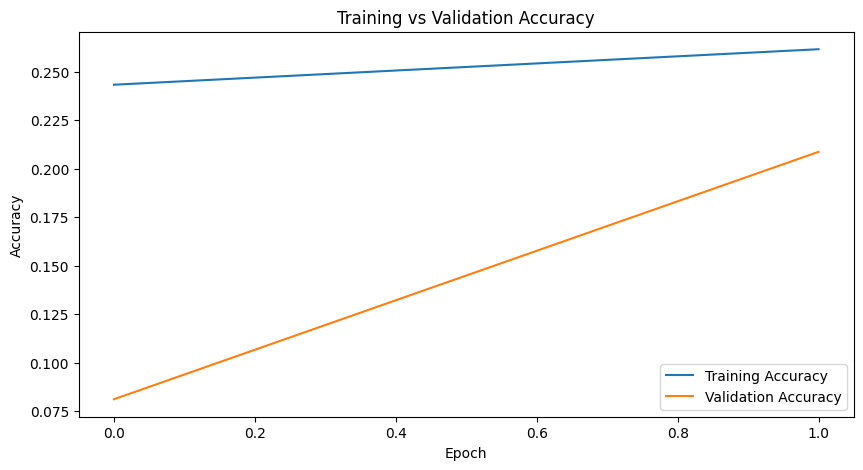

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

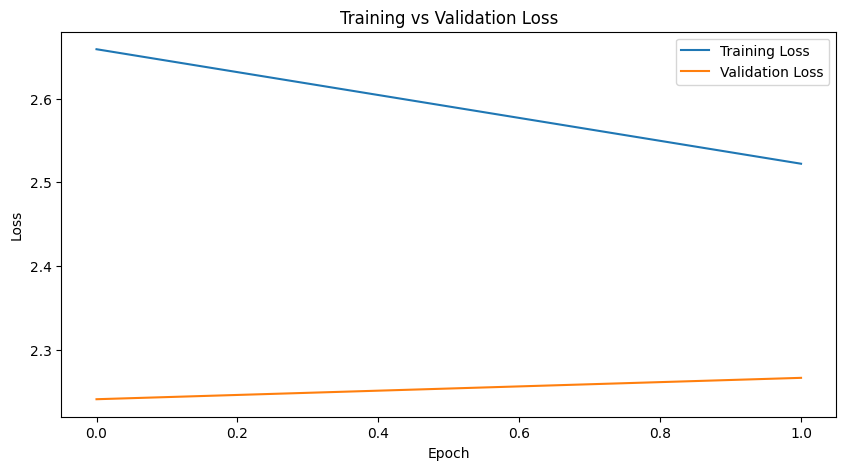

In [32]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [33]:
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=2,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/2
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.2566 - loss: 2.7453
Epoch 1: val_accuracy did not improve from 0.20869
219/219 ━━━━━━━━━━━━━━━━━━━━ 203s 866ms/step - accuracy: 0.2684 - loss: 2.6416 - val_accuracy: 0.0812 - val_loss: 2.7434 - learning_rate: 1.0000e-05
Epoch 2/2
143/219 ━━━━━━━━━━━━━━━━━━━━ 1:09 919ms/step - accuracy: 0.2753 - loss: 2.5536

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_data,
    verbose=1
)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss : {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 413ms/step - accuracy: 0.2715 - loss: 2.2596
Test Accuracy : 27.15%
Test Loss : 2.2596


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 394ms/step


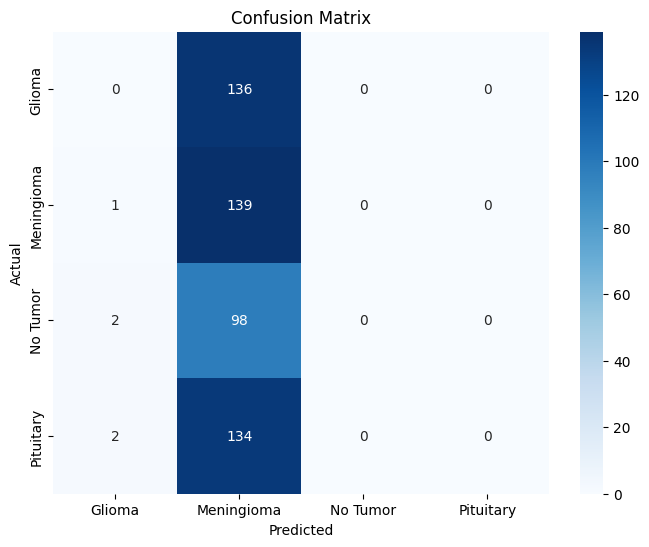

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(test_data.class_indices.keys()),
    yticklabels=list(test_data.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=list(test_data.class_indices.keys())
    )
)

              precision    recall  f1-score   support

      Glioma       0.00      0.00      0.00       136
  Meningioma       0.27      0.99      0.43       140
    No Tumor       0.00      0.00      0.00       100
   Pituitary       0.00      0.00      0.00       136

    accuracy                           0.27       512
   macro avg       0.07      0.25      0.11       512
weighted avg       0.07      0.27      0.12       512



In [ ]:
model.save("BrainTumor_EfficientNetB0.keras")
model.save("BrainTumor_EfficientNetB0.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("BrainTumor_EfficientNetB0.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.2715 - loss: 2.2596
Test Accuracy: 0.271484375


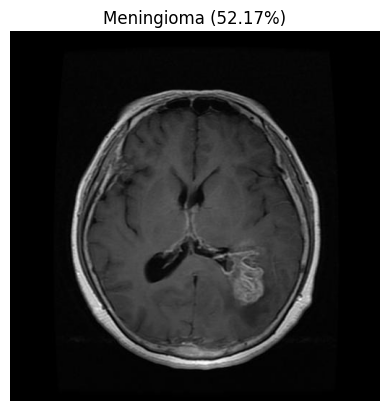

Prediction: Meningioma
Confidence: 52.172535


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = test_df.iloc[0]["filepath"]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

display = image.copy()

image = cv2.resize(image, (224,224))
image = image.astype(np.float32) / 255.0
image = np.expand_dims(image, axis=0)

prediction = model.predict(image, verbose=0)

classes = list(test_data.class_indices.keys())

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(display)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

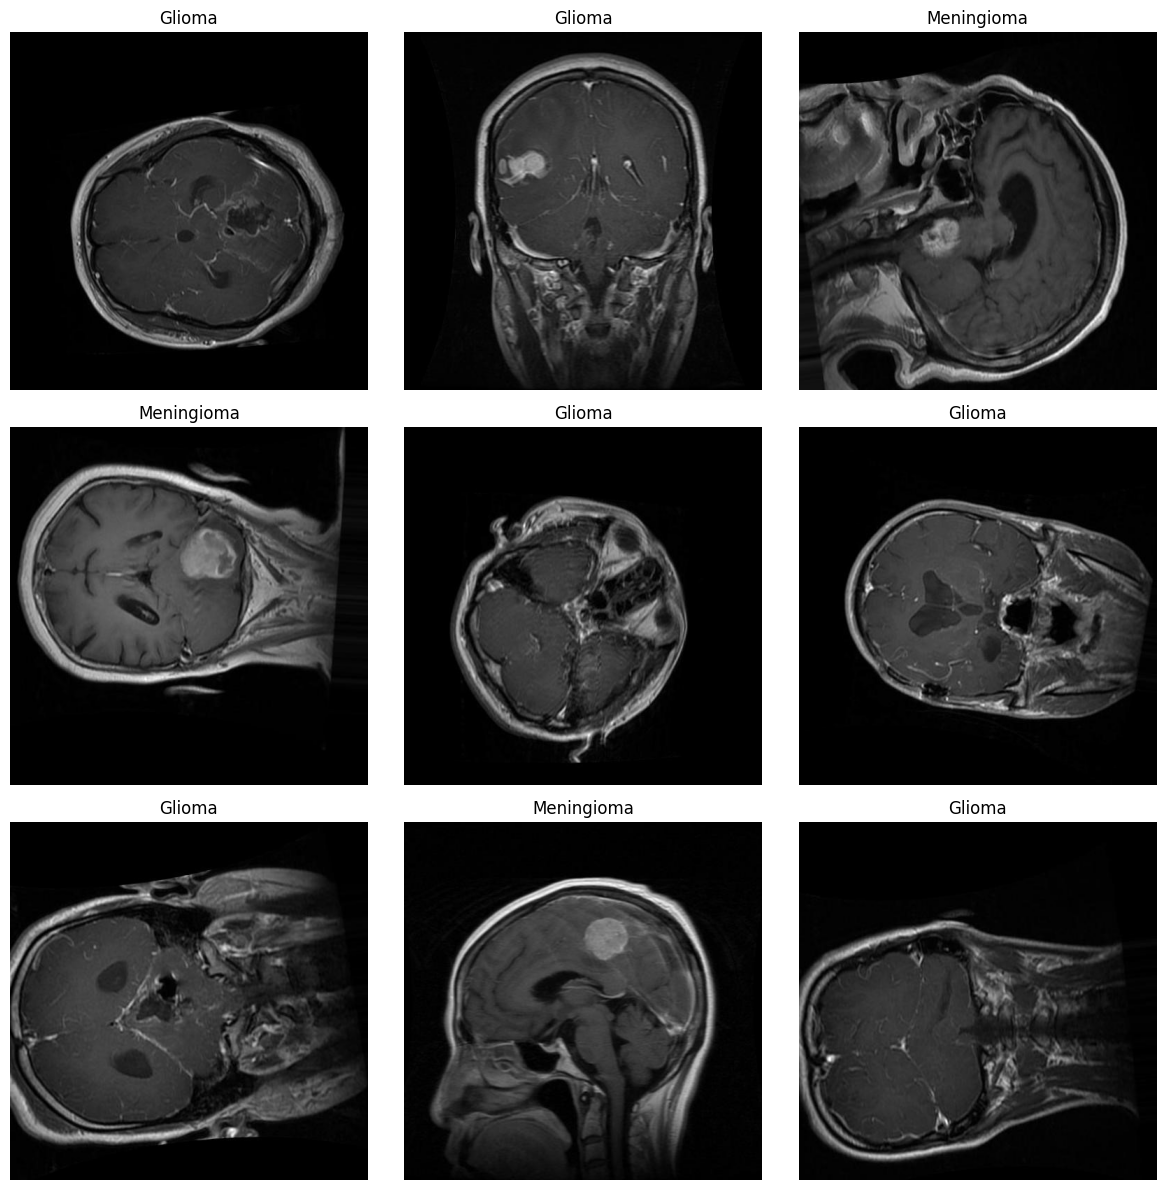

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

plt.figure(figsize=(12,12))

for i in range(9):
    sample = train_df.sample(1).iloc[0]

    img = cv2.imread(sample["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(sample["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(train_df["label"].value_counts())

label
Meningioma    2762
Glioma        2526
Pituitary     1139
No Tumor       569
Name: count, dtype: int64


In [ ]:
images, labels = next(train_data)

print(images.shape)
print(labels.shape)

print(labels[0])

(32, 224, 224, 3)
(32, 4)
[1. 0. 0. 0.]


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:
print("Training Accuracy:")
print(history.history["accuracy"])

print("\nValidation Accuracy:")
print(history.history["val_accuracy"])

print("\nTraining Loss:")
print(history.history["loss"])

print("\nValidation Loss:")
print(history.history["val_loss"])

Training Accuracy:
[0.26129215955734253, 0.25385934114456177]

Validation Accuracy:
[0.16295026242733002, 0.16352201998233795]

Training Loss:
[2.6189208030700684, 2.5447206497192383]

Validation Loss:
[2.115691900253296, 2.05222225189209]


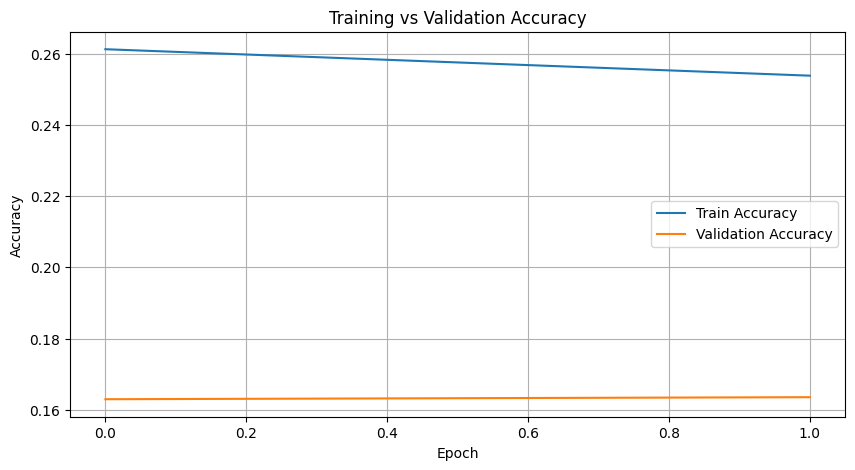

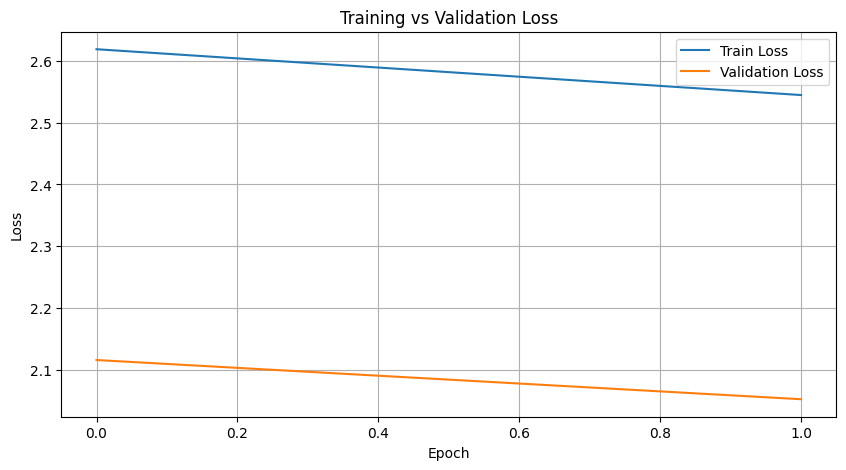

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(model.optimizer.learning_rate.numpy())

1e-05


In [ ]:
model.save("BrainTumor_EfficientNetB0.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!
